In [1594]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [1595]:
import random as rd
import time

In [1596]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end='')
      else:
        print(f'{X[i][j]:d}',end='')
    print()

In [1616]:
def create_matrix(Din,DigitosPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(0*10**(DigitosPorSimbolo-1),1*10**(DigitosPorSimbolo-1))
      Bin[i][j] = rd.randint(0*10**(DigitosPorSimbolo-1),1*10**(DigitosPorSimbolo-1))
  return [Ain,Bin]

10100011
01111001
11010100
00011110
10111111
11010101
00101000
11011011


In [1599]:
Ain@Bin

array([[1, 3, 2, 3, 2, 0, 2, 2],
       [1, 3, 2, 3, 2, 1, 1, 3],
       [0, 3, 4, 2, 2, 1, 2, 1],
       [2, 1, 3, 2, 3, 1, 1, 3],
       [2, 4, 4, 4, 4, 1, 2, 4],
       [0, 4, 4, 3, 2, 1, 2, 2],
       [1, 1, 0, 1, 1, 0, 0, 1],
       [2, 3, 4, 3, 2, 1, 3, 4]])

In [1617]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((2*X1.shape[0]-1,X1.shape[0]),dtype=int)
  Y2 = np.zeros((2*X2.shape[0]-1,X2.shape[0]),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i+j][j] = X1[i][j]
        Y2[i+j][j] = X2[j][i] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


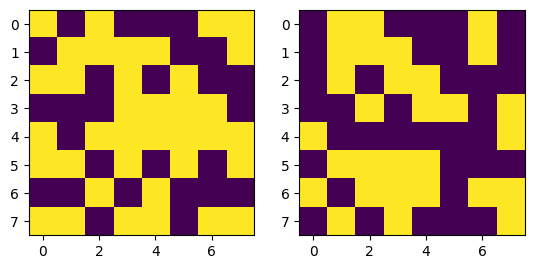

In [1601]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


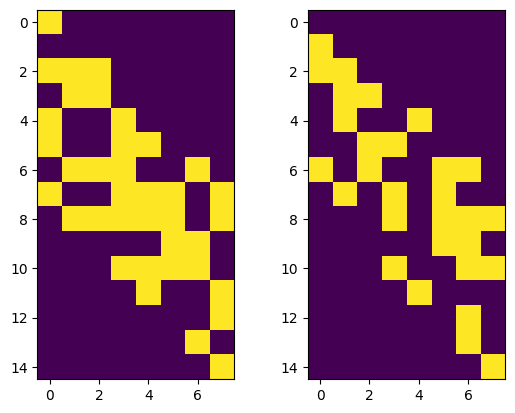

In [1602]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [1718]:
def send_matrix(X):
  s = serial.Serial()
  s.port = "/dev/ttyUSB1"
  s.baudrate = 115200
  s.bytesize = 8
  s.open()
  Fs =10000
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    strbin = ''
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        strbin+=str(X[i][j])
      else:
        strbin+=str(X[i][j])
    print('0b'+strbin,i)
    print(int('0b'+strbin,2))
    s.write(bytearray([int('0b'+strbin,2)]))
    time.sleep(1/Fs)  
  s.write(bytearray([255]))
  s.close()  


In [2126]:
for i in range(10):
    print("----------------------",i,"--------------------------")
    M = create_matrix(Din = 8, DigitosPorSimbolo=1)
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[1])
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------
0b00000000 0
0
0b01000000 1
64
0b11100000 2
224
0b00000000 3
0
0b11100000 4
224
0b11010100 5
212
0b00111110 6
62
0b10111110 7
190
0b00001100 8
12
0b00010111 9
23
0b00011101 10
29
0b00000110 11
6
0b00000010 12
2
0b00000010 13
2
0b00000000 14
0


In [1743]:
M[1]@M[1]

array([[4, 2, 1, 3, 2, 1, 4, 4],
       [4, 2, 1, 3, 2, 2, 4, 4],
       [3, 1, 0, 1, 2, 0, 2, 2],
       [1, 1, 1, 1, 0, 1, 2, 1],
       [3, 1, 1, 3, 0, 1, 2, 3],
       [5, 3, 1, 4, 2, 2, 5, 5],
       [5, 1, 1, 3, 2, 0, 3, 4],
       [3, 1, 2, 2, 1, 1, 4, 3]])

In [1698]:
s = serial.Serial()

s.port = "/dev/ttyUSB1"
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [1707]:
i =1
s.write(bytearray([int(i)]))


1

In [1606]:
serial.Serial()

Serial<id=0x7f7d3d806800, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)